In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift, ifft2, ifftshift

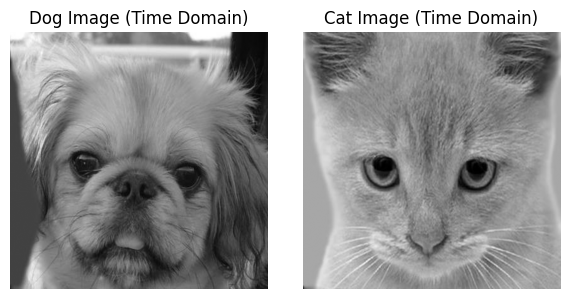

In [4]:
# Load and show images
dog = Image.open("data/dog_gray.jpg").resize((512, 512)).convert("L")
cat = Image.open("data/cat_gray.jpg").resize((512, 512)).convert("L")

arr_dog = np.array(dog)
arr_cat = np.array(cat)

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(arr_dog, cmap='gray')
plt.title('Dog Image (Time Domain)')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(arr_cat, cmap='gray')
plt.title('Cat Image (Time Domain)')
plt.axis('off')
plt.tight_layout()
plt.show()


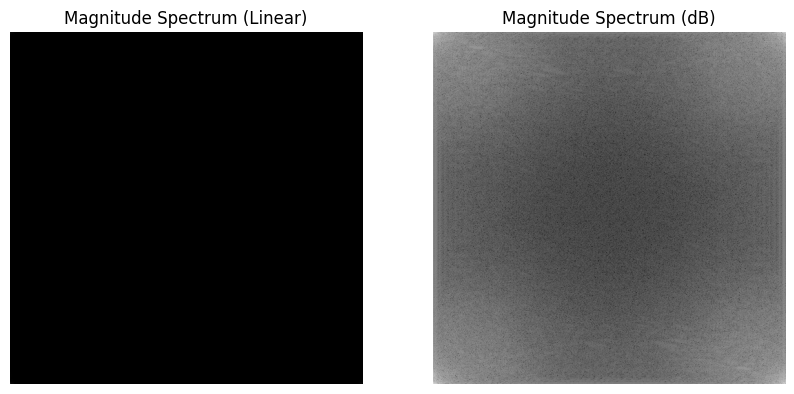

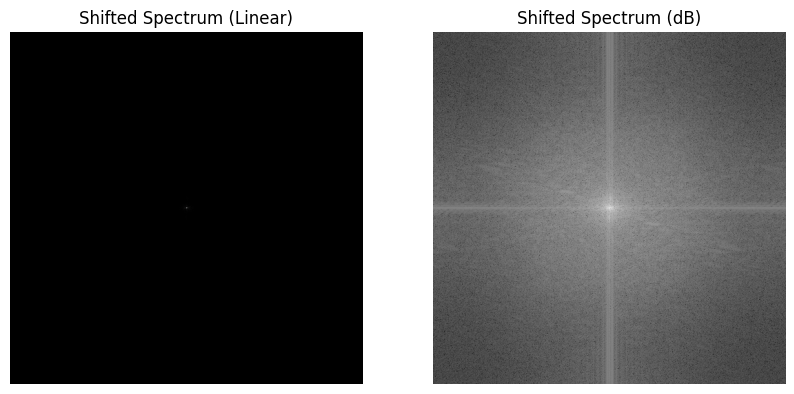

In [6]:

# FFT and magnitude spectrum
f = fft2(arr_dog)
f_shift = fftshift(f)

magnitude = np.abs(f)
mag_db = 20 * np.log10(magnitude + 1e-5)
mag_shift = np.abs(f_shift)
mag_shift_db = 20 * np.log10(mag_shift + 1e-5)

plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.imshow(magnitude, cmap='gray')
plt.title('Magnitude Spectrum (Linear)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mag_db, cmap='gray')
plt.title('Magnitude Spectrum (dB)')
plt.axis('off')
plt.show()

plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.imshow(mag_shift, cmap='gray')
plt.title('Shifted Spectrum (Linear)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mag_shift_db, cmap='gray')
plt.title('Shifted Spectrum (dB)')
plt.axis('off')
plt.show()


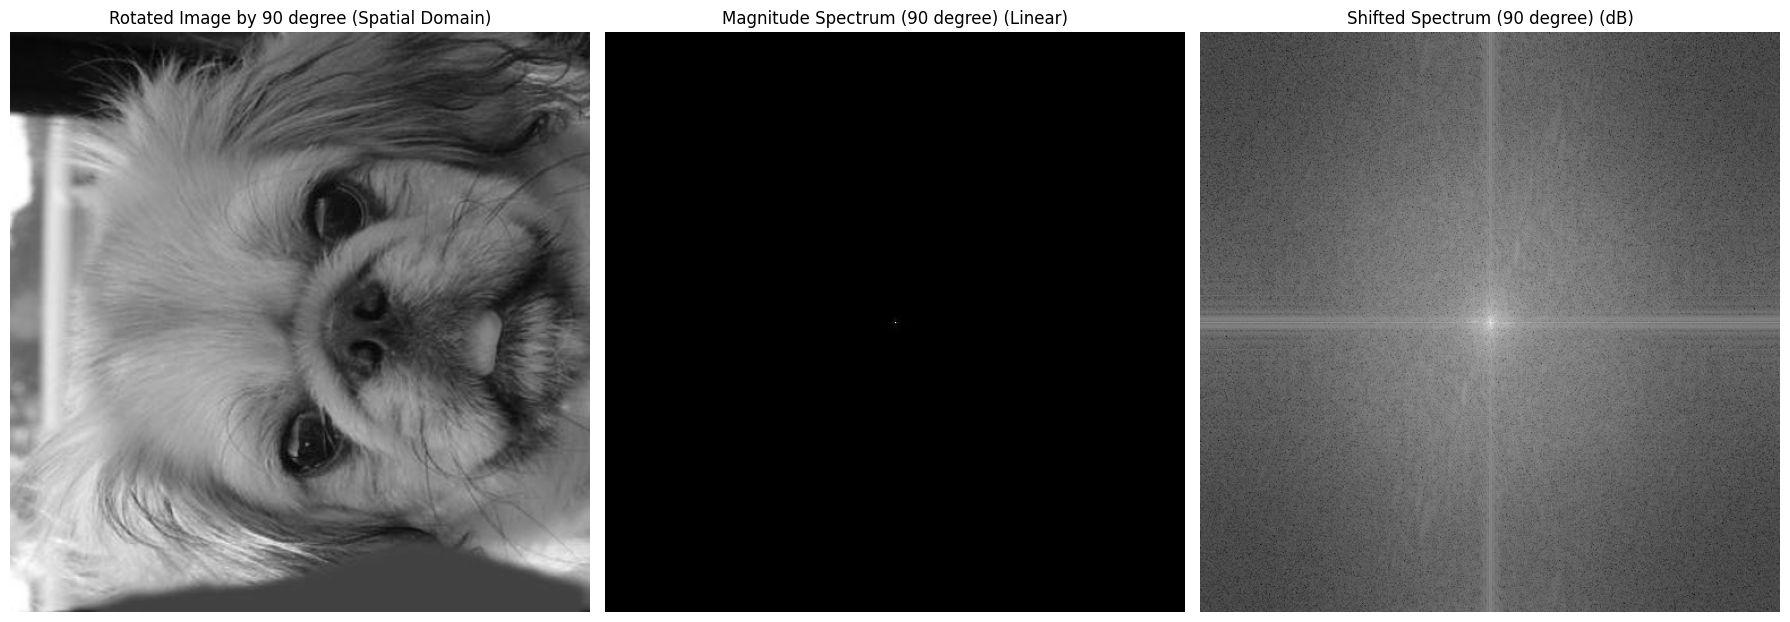

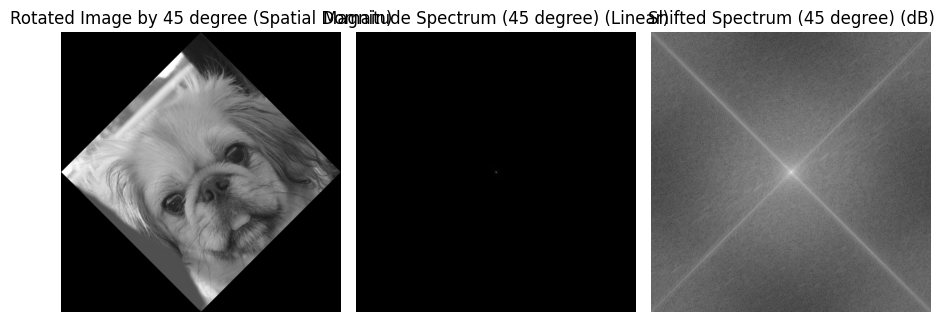

In [10]:
# Rotated image and its spectrum
rotated_90 = np.rot90(arr_dog)
rotated_45 = dog.rotate(45, expand=True)  # expand=True to fit the whole rotated image


fft_rot_90 = fft2(rotated_90)
fft_rot_shift_90 = fftshift(fft_rot_90)
mag_rot_shift_90 = np.abs(fft_rot_shift_90)
mag_rot_shift_db_90 = 20 * np.log10(mag_rot_shift_90 + 1e-5)

#plotting for 90 degree rotation
plt.figure(figsize=(18,10))
plt.subplot(1, 3, 1)
plt.imshow(rotated_90, cmap='gray')
plt.title('Rotated Image by 90 degree (Spatial Domain)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mag_rot_shift_90, cmap='gray')
plt.title('Magnitude Spectrum (90 degree) (Linear)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(mag_rot_shift_db_90, cmap='gray')
plt.title('Shifted Spectrum (90 degree) (dB)')
plt.axis('off')
plt.tight_layout()
plt.show()

fft_rot_45 = fft2(rotated_45)
fft_rot_shift_45 = fftshift(fft_rot_45)
mag_rot_shift_45 = np.abs(fft_rot_shift_45)
mag_rot_shift_db_45 = 20 * np.log10(mag_rot_shift_45 + 1e-5)

#plotting for 45 degree rotation
plt.figure(figsize=(9,6))
plt.subplot(1, 3, 1)
plt.imshow(rotated_45, cmap='gray')
plt.title('Rotated Image by 45 degree (Spatial Domain)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mag_rot_shift_45, cmap='gray')
plt.title('Magnitude Spectrum (45 degree) (Linear)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(mag_rot_shift_db_45, cmap='gray')
plt.title('Shifted Spectrum (45 degree) (dB)')
plt.axis('off')
plt.tight_layout()
plt.show()



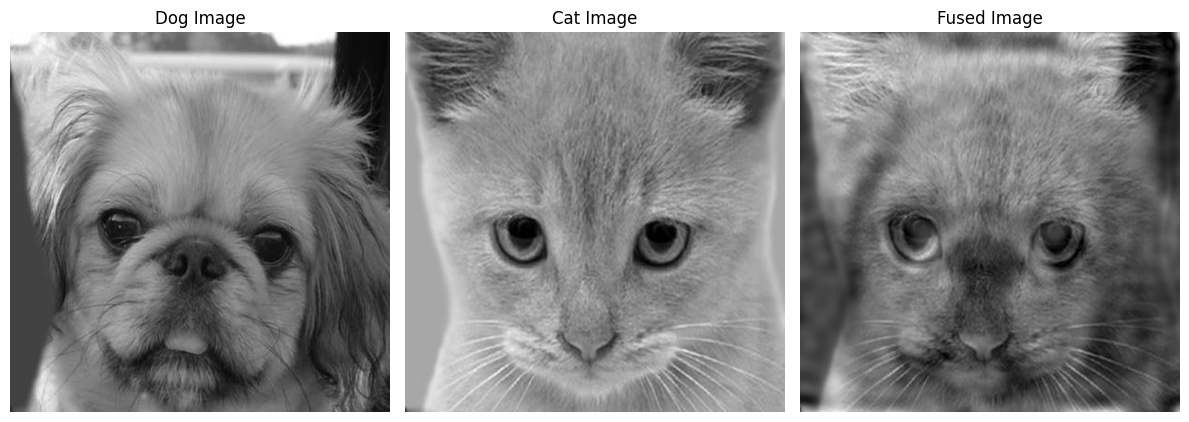

In [93]:
arr_dog = np.array(dog, dtype=np.float32)
arr_cat = np.array(cat, dtype=np.float32)

# FFT and shift
F_dog = fftshift(fft2(arr_dog))
F_cat = fftshift(fft2(arr_cat))

# Magnitude and Phase
mag_dog, phase_dog = np.abs(F_dog), np.angle(F_dog)
mag_cat, phase_cat = np.abs(F_cat), np.angle(F_cat)

# Create circular low-pass mask
h, w = arr_dog.shape
centre_h, centre_w = h // 2, w // 2
sigma = 15
Y, X = np.ogrid[:h, :w]
dist = np.sqrt((X - centre_w)**2 + (Y - centre_h)**2)
lpm = np.exp(-(dist**4) / (2 * sigma**4))
hpm = 1 - lpm

# Fuse magnitude and phase
mag = mag_dog * lpm + mag_cat * hpm
phase = phase_dog * lpm + phase_cat * hpm

# Combine to form fused frequency domain representation
F = mag * np.exp(1j * phase)
img_fused = np.abs(ifft2(ifftshift(F)))

# Show results
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(arr_dog, cmap='gray')
plt.title('Dog Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(arr_cat, cmap='gray')
plt.title('Cat Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_fused, cmap='gray')
plt.title('Fused Image')
plt.axis('off')
plt.tight_layout()
plt.show()

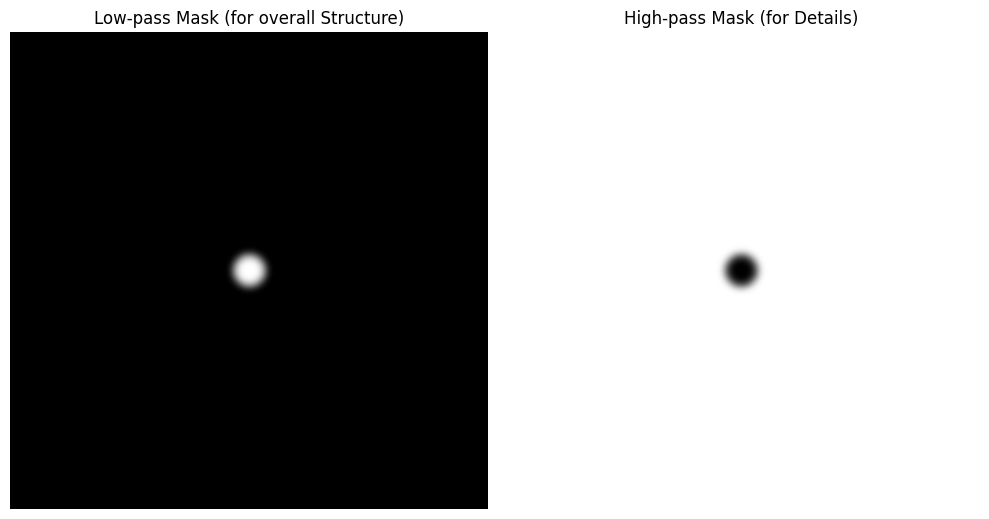

In [94]:

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(lpm, cmap='gray')
plt.title('Low-pass Mask (for overall Structure)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hpm, cmap='gray')
plt.title('High-pass Mask (for Details)')
plt.axis('off')
plt.tight_layout()
plt.show()